# Wave Spectra Post-Processing

**Runnable companion to [`swan-model-guide.md`](../swan-model-guide.md) and
[`ww3-model-guide.md`](../ww3-model-guide.md).**

SWAN and WAVEWATCH III output the **2-D directional energy spectrum**
`E(f, θ)`. Everything operational — significant wave height, peak period, mean
direction — is an integral of that spectrum. This notebook builds a realistic
JONSWAP spectrum and shows how to read it: the polar plot, the 1-D frequency
spectrum, and the integrated bulk parameters.

> The spectrum is generated by `meteo_examples.sampledata.make_wave_spectrum`.
> The integration code below is exactly what you apply to a real spectrum read
> from a SWAN `.spec` file or a WW3 spectral NetCDF (`efth`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from meteo_examples import sampledata

freq, theta, E2d, hs_check = sampledata.make_wave_spectrum()
# np.trapz was renamed np.trapezoid in NumPy 2.0
trapz = getattr(np, "trapezoid", None) or np.trapz
plt.rcParams["figure.dpi"] = 110
print(f"E(f, θ) shape: {E2d.shape}  (n_freq={len(freq)}, n_dir={len(theta)})")

E(f, θ) shape: (30, 36)  (n_freq=30, n_dir=36)


## 1 · The 2-D directional spectrum (polar)

Energy concentrated in a narrow band of frequency and direction = a clean swell;
broad spreading = a wind sea. Convention here: direction is where waves come
**from** (oceanographic 'coming-from').

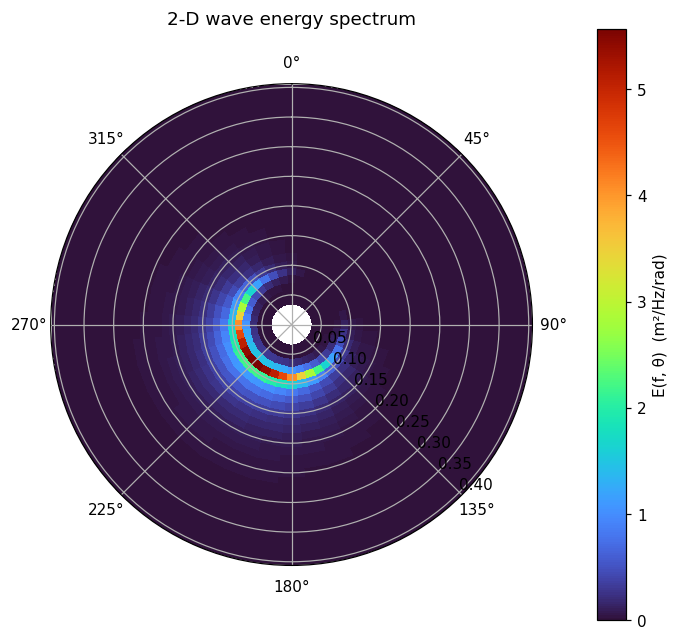

In [2]:
fig = plt.figure(figsize=(6.5, 6))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
TH, FR = np.meshgrid(theta, freq)
pcm = ax.pcolormesh(TH, FR, E2d, cmap="turbo", shading="auto")
plt.colorbar(pcm, label="E(f, θ)  (m²/Hz/rad)", pad=0.1)
ax.set_title("2-D wave energy spectrum", pad=20)
ax.set_rlabel_position(135); plt.tight_layout()

## 2 · 1-D frequency spectrum

Integrate over direction to get `E(f)`. The peak frequency `fp` gives the peak
period `Tp = 1/fp`.

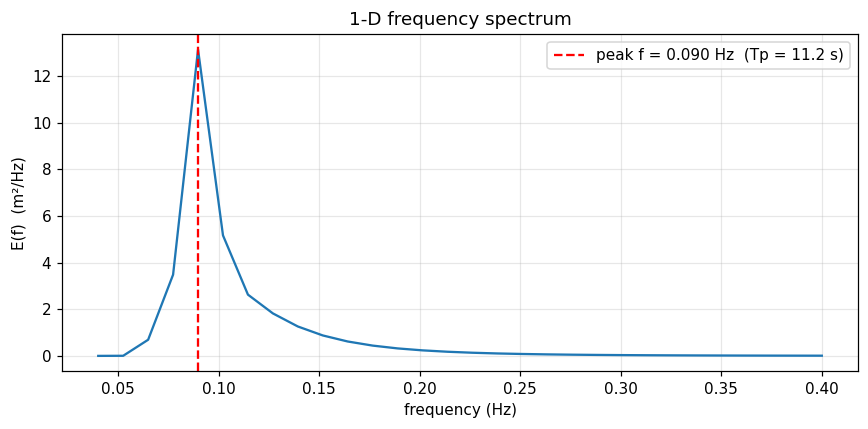

In [3]:
Ef = trapz(E2d, theta, axis=1)          # integrate over direction
fp = freq[np.argmax(Ef)]
Tp = 1.0 / fp

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(freq, Ef, color="C0")
ax.axvline(fp, color="r", ls="--", label=f"peak f = {fp:.3f} Hz  (Tp = {Tp:.1f} s)")
ax.set(xlabel="frequency (Hz)", ylabel="E(f)  (m²/Hz)", title="1-D frequency spectrum")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()

## 3 · Bulk parameters from spectral moments

The spectral moments `mₙ = ∬ fⁿ E(f,θ) df dθ` give every bulk parameter:

- Significant wave height **Hs = 4√m₀**
- Mean period **Tm01 = m₀/m₁**
- Mean direction from the directional moments.

In [4]:
m0 = trapz(trapz(E2d, theta, axis=1), freq)
m1 = trapz(freq * trapz(E2d, theta, axis=1), freq)
Hs = 4 * np.sqrt(m0)
Tm01 = m0 / m1

# Mean wave direction from the first directional moments
a1 = trapz(trapz(E2d * np.cos(theta)[None, :], theta, axis=1), freq)
b1 = trapz(trapz(E2d * np.sin(theta)[None, :], theta, axis=1), freq)
mean_dir = np.degrees(np.arctan2(b1, a1)) % 360

print(f"Significant wave height  Hs   = {Hs:.2f} m")
print(f"Peak period              Tp   = {Tp:.1f} s")
print(f"Mean period              Tm01 = {Tm01:.1f} s")
print(f"Mean wave direction           = {mean_dir:.0f}°")

Significant wave height  Hs   = 2.50 m
Peak period              Tp   = 11.2 s
Mean period              Tm01 = 9.4 s
Mean wave direction           = 225°


---
### Apply to your own output

```python
# WAVEWATCH III spectral NetCDF
import xarray as xr
ds = xr.open_dataset("ww3.spec.nc")
E2d = ds["efth"].isel(time=0, station=0).values   # (freq, direction)
freq, theta = ds["frequency"].values, np.deg2rad(ds["direction"].values)
# ... the moment integration above is identical
```

Then verify Hs against buoys with
[`../../observations/notebooks/ocean_obs_access.ipynb`](../../observations/notebooks/ocean_obs_access.ipynb)
and the **scatter index** (see the verification guide).